In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'./Dataset/extracted_dataset/non-multisegment/non-multisegment_input.csv')

df.head()

,filename,Event,EventTAG,LAT,LON,DEP,LEN_f,WID,Mw,Mo,...,HR-GPS-Data,Hr-GPS-Data,InSAR-Data,Other-Data,SAT-Data,SPOT-Data,hr-GPS-Data,inSAR-Data,level-Data,tril-Data
0,s1906SANFRA01SONG.fsp,San Francisco (Calif.),s1906SANFRA01SONG,37.78,-122.51,10.0,480.0,12.0,7.91,8.150000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s1906SANFRA01THAT.fsp,San Francisco (Calif.),s1906SANFRA01THAT,37.78,-122.51,10.0,480.0,10.0,7.91,8.120000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s1923KANTOJ01KOBA.fsp,Kanto (Japan),s1923KANTOJ01KOBA,35.40,139.20,14.6,130.0,70.0,8.08,1.460000e+21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s1923KANTOJ01WALD.fsp,Kanto (Japan),s1923KANTOJ01WALD,35.40,139.20,14.6,130.0,70.0,7.95,9.330000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s1944TONANK01ICHI.fsp,Tonankai (Japan),s1944TONANK01ICHI,33.77,135.96,30.0,220.0,140.0,8.04,1.310000e+21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
import os

# Path to the folder containing the images
image_folder = r'Dataset\all_images'

# Check if the folder exists
if os.path.exists(image_folder):
    # Get all files in the folder
    image_files = [f[24:-4] for f in os.listdir(image_folder) if os.path.isfile(os.path.join(image_folder, f))]
    
    # Print the number of files found
    print(f"Found {len(image_files)} files in {image_folder} folder")
    
    # Display the first few filenames
    if image_files:
        print("First 5 filenames:")
        for file in image_files[:5]:
            print(file)
else:
    print(f"The folder '{image_folder}' does not exist.")

Found 200 files in Dataset\all_images folder
First 5 filenames:
s1923KANTOJ01KOBA.fsp
s1923KANTOJ01WALD.fsp
s1944TONANK01ICHI.fsp
s1944TONANK01KATO.fsp
s1944TONANK01KIKU.fsp


In [19]:
# Create a map for Dz values and save as JSON
import json

# Initialize the map for Dz values
dz_map = {}

# Select the columns we need (filename and Dz)
dz_cols = ['filename', 'Dz']

# Check if Dz column exists in the dataframe
if 'Dz' in df.columns:
    for row in df[dz_cols].iterrows():
        filename = row[1].values[0]  # Keep the .fsp extension for consistency
        dz_value = row[1].values[1]
        
        # Only add if Dz value is not NaN
        if not pd.isna(dz_value):
            dz_map[filename[:-4]] = float(dz_value)
    
    # Save the map as JSON
    with open(r'assets/dz.json', 'w') as f:
        json.dump(dz_map, f, indent=2)
    
    print(f"Created dz.json with {len(dz_map)} entries")
    print(f"Sample entries: {dict(list(dz_map.items())[:5])}")
else:
    print("Warning: 'Dz' column not found in the dataframe")
    print(f"Available columns: {df.columns.tolist()}")



Created dz.json with 355 entries
Sample entries: {'s1906SANFRA01SONG': 12.0, 's1906SANFRA01THAT': 10.0, 's1923KANTOJ01KOBA': 10.0, 's1923KANTOJ01WALD': 10.0, 's1944TONANK01ICHI': 20.0}


In [21]:
selected_cols= [
    'filename', # Name of the file containing the fault or subfault data
    'LAT',      # Latitude of the fault or subfault patch
    'LON',      # Longitude of the fault or subfault patch
    'DEP',      # Depth of the fault or subfault patch
    'STRK',     # Strike angle (orientation of the fault relative to North)
    'DIP',      # Dip angle (steepness of the fault plane)
    'RAKE',     # Rake angle (direction of slip)
    'LEN_f',    # Fault length (if known before the event)
    'WID',      # Fault width (if known before the event)
    'Htop',     # Depth to the top of the fault
    'HypX',     # Hypocenter location along the fault's length
    'HypZ',     # Hypocenter location along the fault's width
    'Nx',       # Number of subfaults along strike
    'Nz',       # Number of subfaults along dip
    'Dx',       # Length of each subfault patch
    'Dz',       # Width of each subfault patch
    'Mw'        # Moment Magnitude
]

Plotting distributions for: ['LAT', 'LON', 'DEP', 'STRK', 'DIP', 'RAKE', 'LEN_f', 'WID', 'Htop', 'HypX', 'HypZ', 'Nx', 'Nz', 'Dx', 'Dz', 'Mw']


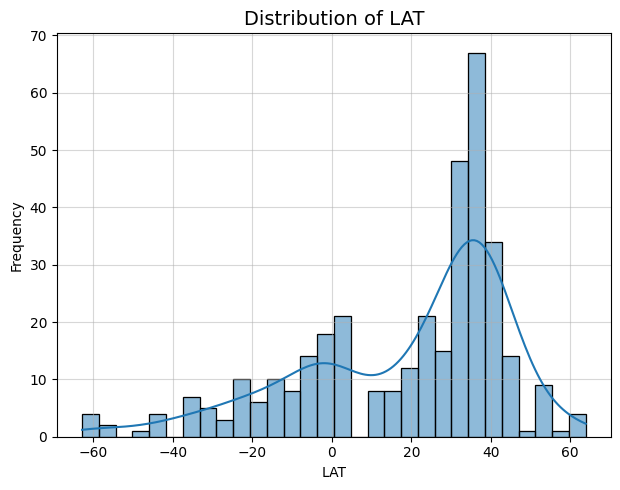

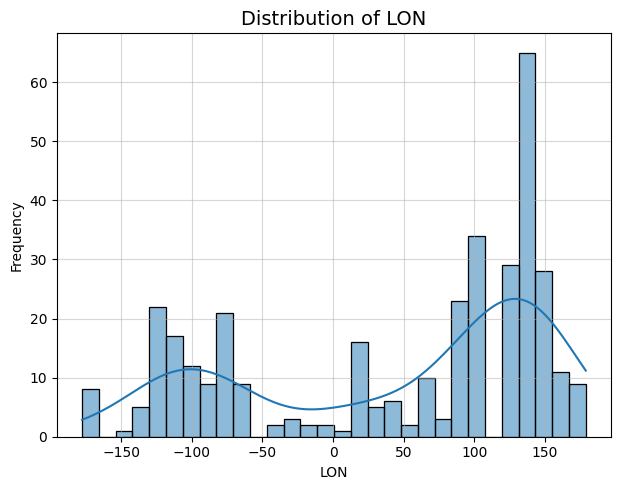

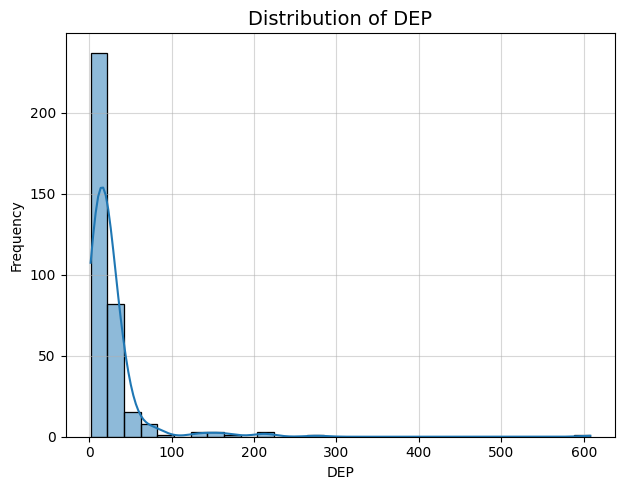

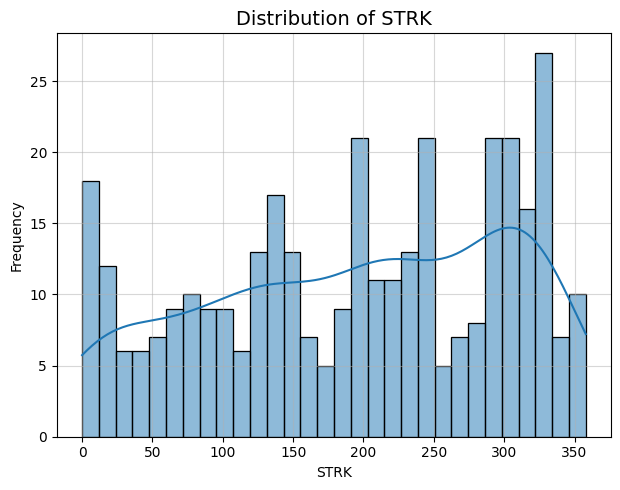

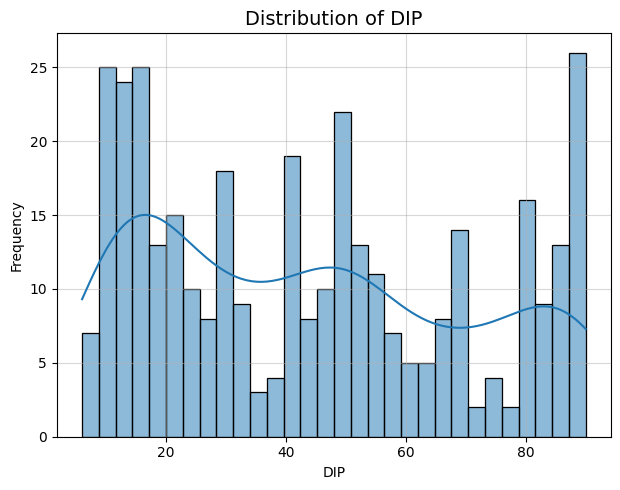

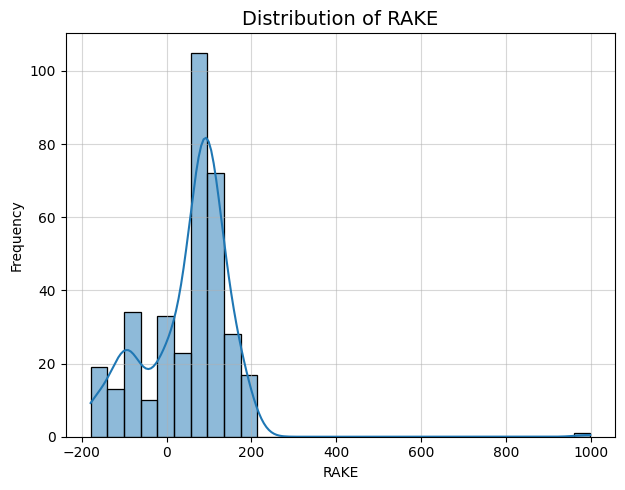

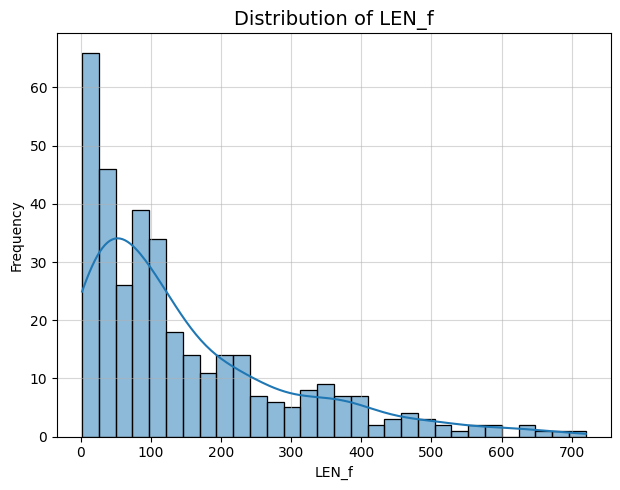

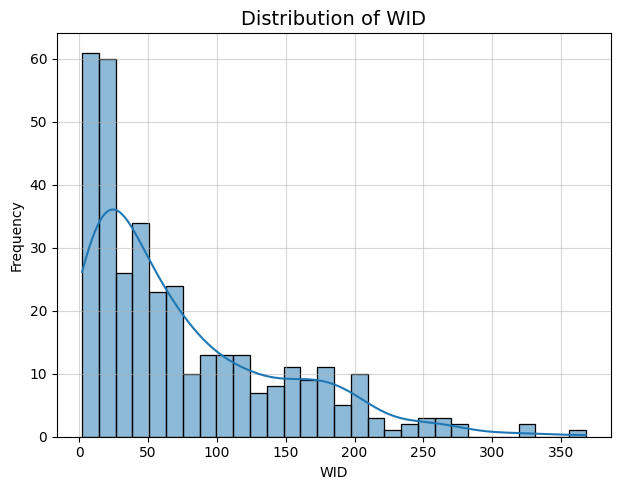

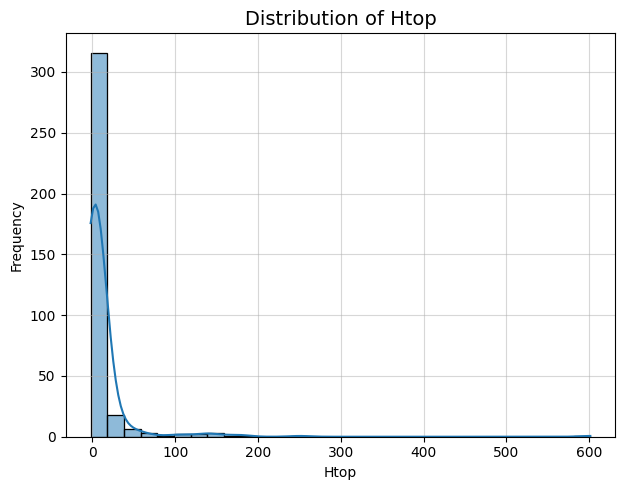

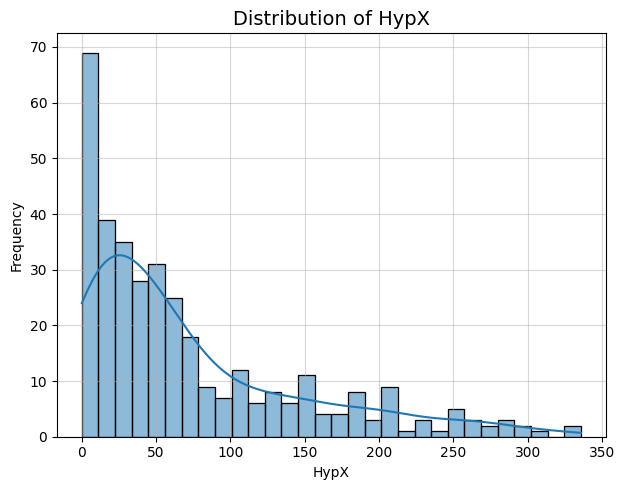

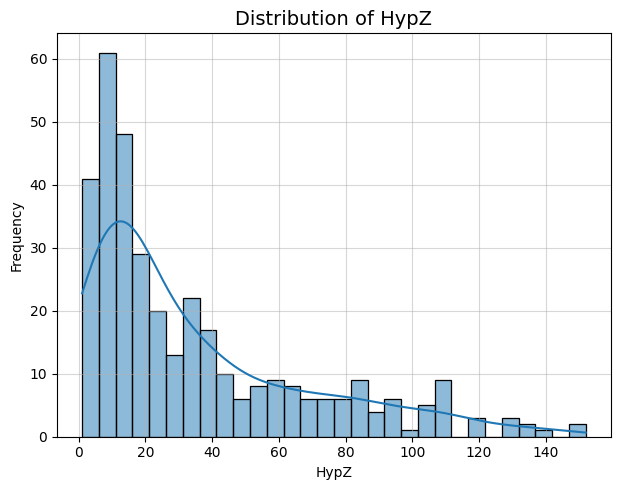

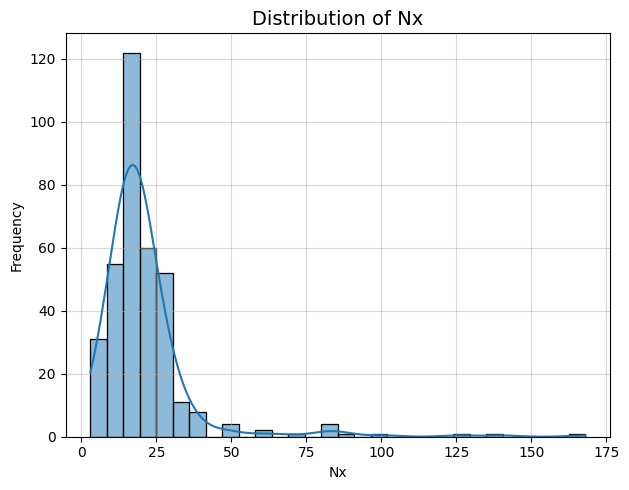

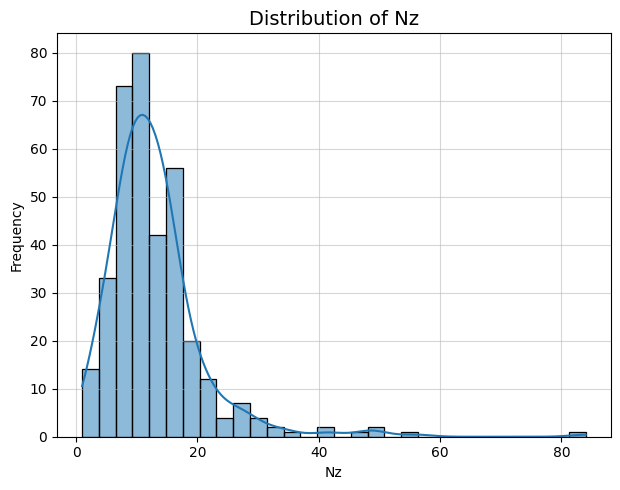

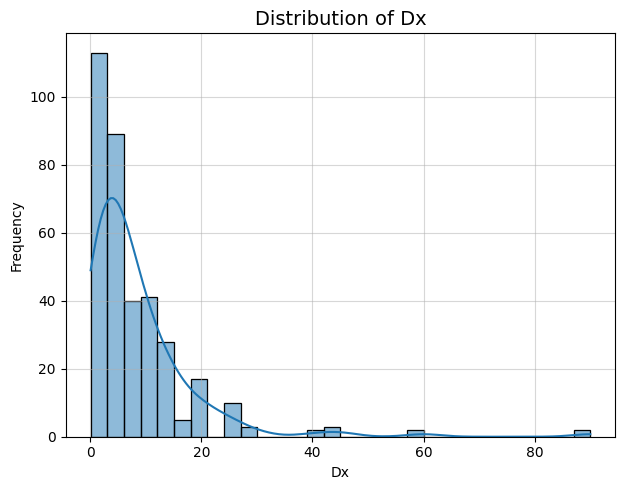

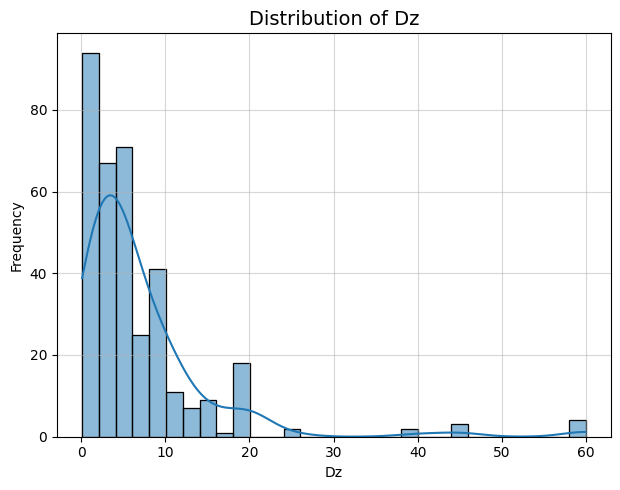

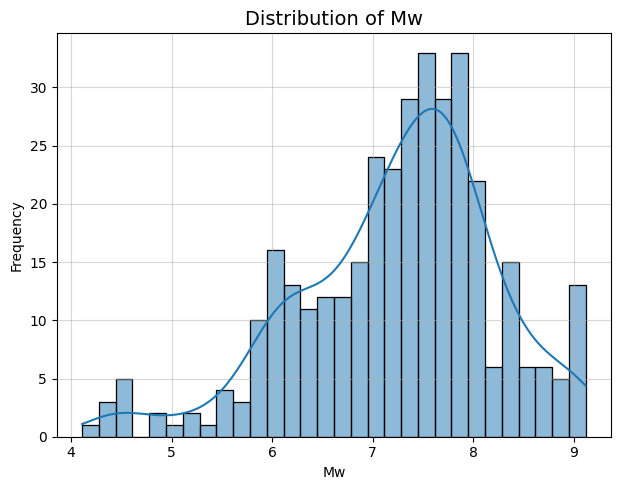

In [22]:
# --- Step 3: Plot distributions if data is loaded ---
if not df.empty:
    # Find which of the selected columns are actually in the DataFrame
    existing_cols = [col for col in selected_cols if col in df.columns]
    
    # Isolate the numerical columns for plotting
    numerical_cols = [col for col in existing_cols if pd.api.types.is_numeric_dtype(df[col])]
    
    print(f"Plotting distributions for: {numerical_cols}")

    # --- Step 4: Loop through and plot each numerical column ---
    for col in numerical_cols:
        # Plot 1: Original Distribution
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1) # Create a subplot for the original distribution
        sns.histplot(df[col].dropna(), kde=True, bins=30)
        plt.title(f'Distribution of {col}', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Frequency')
        
        plt.grid(True, alpha=0.5)
        plt.tight_layout()
        plt.show()
else:
    print("DataFrame is empty. Cannot generate plots.")


In [23]:
map = {}

for row in df[selected_cols].iterrows():
    # print(row)
    filename = row[1].values[0][:-4]
    # break
    if filename not in map:
        map[filename] = row[1].values[1:]

In [24]:
map[list(map.keys())[0]].shape

(16,)

In [25]:
import numpy as np

# Save the map as a .npy file
np.save(r'Dataset/text_vec.npy', map)
print(f"Saved text_vec.npy with {len(map)} entries")

Saved text_vec.npy with 355 entries
